In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyspark.sql.functions as f
import scipy.stats as stats
import statsmodels.api as sm
from gentropy.common.session import Session


Loading BokehJS ...

/Users/dc16/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [3]:
session = Session(extended_spark_conf={"spark.driver.memory": "10g"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/05 12:19:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
release_path = "../../../data/25.06/output/"
output_path = "../../../data/intermediate_files/"


# Process human knock-out data


In [ ]:
hko_data = session.spark.read.csv("/users/dc16/Downloads/41586_2024_7556_MOESM8_ESM.csv", header=True)
hko_data.count()


4848

In [6]:
target = session.spark.read.parquet(f"{release_path}target").select(
    f.col("id").alias("targetId"), "canonicalTranscript.id"
)
hko_processed = (
    target.join(hko_data.select("transcriptId"), target["id"] == hko_data["TranscriptId"], "inner")
    .drop("id", "transcriptId")
    .withColumn("source", f.lit("human_ko"))
)


In [7]:
hko_processed.distinct().count()


4445

In [ ]:
category_mapping = {
    "all_diseases": "GWAS",
    "cancer_ChEMBL": "Cancer ChEMBL",
    "gene_burden": "Gene-based analysis",
    "omim": "OMIM",
    "cancer_driver_gene": "Cancer Driver (COSMIC)",
    "withdrawn_drug": "Withdrawn Drug",
    "non_cancer_ChEMBL": "Non-Cancer ChEMBL",
    "essential_gene": "Essential Gene (DepMap)",
    "gwas_eQTL": "GWAS with eQTL evidence",
    "gwas_with_pav": "GWAS with PAV evidence",
    "liable_target": "Known safety events",
    "orphanet": "Orphanet",
    "ChEMBL": "ChEMBL",
    "dd_related": "DD panel (gene2phenotype)",
    "pharmacogene": "Pharmacogenetics - Toxicity",
    "trial_safety_concern": "Trial Safety",
    "mouse_ko_mortality": "Mouse KO Mortality",
    "All genes": "All protein-coding genes",
    "fusil_CL": "Cellular lethal (FUSIL)",
    "fusil_DL": "Developmental lethal (FUSIL)",
    "fusil_SV": "Subviable (FUSIL)",
    "fusil_VP": "Viable with phenotype (FUSIL)",
    "fusil_VN": "Viable with no phenotype (FUSIL)",
    "lof_constr_Q4": "Q4 LoF constraint",
    "lof_constr_Q3": "Q3 LoF constraint",
    "lof_constr_Q2": "Q2 LoF constraint",
    "lof_constr_Q1": "Q1 LoF constraint",
    "non_essential": "Non-essential Gene (DepMap)",
    "distant_ortholog": "Drosophila distant orthologs",
    "human_ko": "Human Knockout",
}


In [ ]:
categories_to_include = [
    "Gene-based analysis",
    "OMIM",
    "Cancer Driver (COSMIC)",
    "Withdrawn Drug",
    "Essential Gene (DepMap)",
    "Known safety events",
    "Orphanet",
    "ChEMBL",
    "DD panel (gene2phenotype)",
    "Trial Safety",
    "Mouse KO Mortality",
    "Cellular lethal (FUSIL)",
    "Developmental lethal (FUSIL)",
    "Subviable (FUSIL)",
    "Viable with phenotype (FUSIL)",
    "Viable with no phenotype (FUSIL)",
    "Q4 LoF constraint",
    "Q1 LoF constraint",
    "GWAS",
    "Non-essential Gene (DepMap)",
    "Drosophila distant orthologs",
    "Human Knockout",
]


In [ ]:
gene_categories = (
    session.spark.read.parquet(f"{output_path}list_of_genes_32_categories")
    .unionByName(hko_processed)
    .replace(category_mapping, subset=["source"])
    .filter(f.col("source").isin(categories_to_include))
    .groupBy("targetId")
    .agg(f.collect_set("source").alias("source"))
)
genes_pleiotropy = session.spark.read.parquet(f"{output_path}genes_pleiotropy").select(
    "geneId", "uniqueDiseases", "uniqueTherapeuticAreas", "totalStudies"
)
genes_pleiotropy_categories = genes_pleiotropy.join(
    gene_categories, genes_pleiotropy.geneId == gene_categories.targetId, "inner"
).drop("targetId")


In [17]:
genes_pleiotropy_categories.show()


+---------------+--------------+----------------------+------------+--------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|totalStudies|              source|
+---------------+--------------+----------------------+------------+--------------------+
|ENSG00000000003|             2|                     2|           3|              [GWAS]|
|ENSG00000000457|             3|                     3|           5|              [GWAS]|
|ENSG00000000460|             2|                     2|           4|[GWAS, Developmen...|
|ENSG00000000971|            17|                     5|          70|[OMIM, Gene-based...|
|ENSG00000001036|             2|                     1|           2|[Human Knockout, ...|
|ENSG00000001084|             2|                     1|           3|[OMIM, GWAS, Viab...|
|ENSG00000001167|             1|                     1|           1|              [GWAS]|
|ENSG00000001460|             1|                     1|           1|              [GWAS]|
|ENSG00000

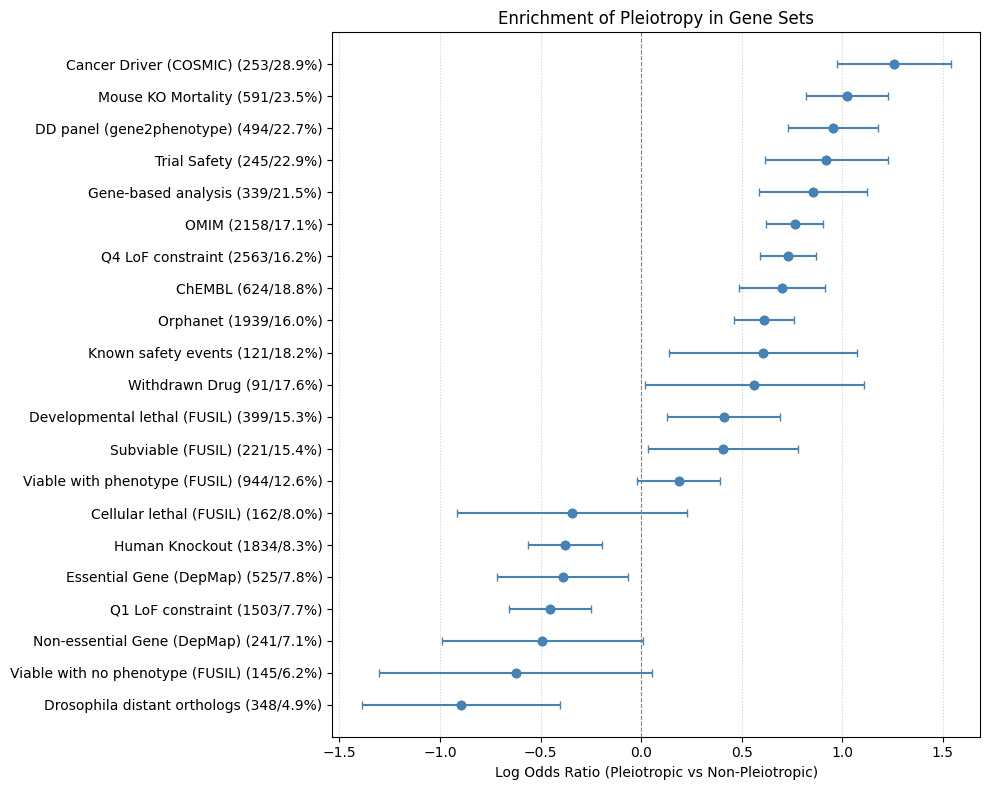

In [18]:
# 1. Convert to Pandas for easier manipulation
df_pd = genes_pleiotropy_categories.toPandas()

# 2. Define Binary Outcome: Pleiotropic if uniqueDiseases >= 10
df_pd["is_pleiotropic"] = df_pd["uniqueDiseases"] >= 10

# 3. Explode the 'source' column to get one row per gene-category pair
df_exploded = df_pd.explode("source")

# 4. Calculate ORs for each category
results = []
all_categories = df_exploded["source"].unique()
total_genes = len(df_pd)
overall_pleiotropic_count = df_pd["is_pleiotropic"].sum()

for category in all_categories:
    if category is None:
        continue

    # Identify genes in this category
    genes_in_cat_ids = df_exploded[df_exploded["source"] == category]["geneId"].unique()

    # Create 2x2 Contingency Table
    #           | Pleiotropic | Not Pleiotropic
    # In Cat    |      a      |       b
    # Not In Cat|      c      |       d

    in_cat = df_pd["geneId"].isin(genes_in_cat_ids)

    a = df_pd[in_cat & df_pd["is_pleiotropic"]].shape[0]
    b = df_pd[in_cat & (~df_pd["is_pleiotropic"])].shape[0]
    c = df_pd[(~in_cat) & df_pd["is_pleiotropic"]].shape[0]
    d = df_pd[(~in_cat) & (~df_pd["is_pleiotropic"])].shape[0]

    # Calculate Odds Ratio and p-value (Fisher's Exact Test or Chi2)
    # Using explicit indexing to avoid Pylance inference issues with unpacking
    fisher_result = stats.fisher_exact([[a, b], [c, d]])
    odds_ratio = fisher_result[0]
    p_value = fisher_result[1]

    # Calculate 95% CI for Log Odds Ratio
    # SE = sqrt(1/a + 1/b + 1/c + 1/d)
    if a > 0 and b > 0 and c > 0 and d > 0:
        log_or = np.log(odds_ratio)
        se_log_or = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
        # CI for OR
        ci_lower = np.exp(log_or - 1.96 * se_log_or)
        ci_upper = np.exp(log_or + 1.96 * se_log_or)
        # CI for Log OR
        log_ci_lower = log_or - 1.96 * se_log_or
        log_ci_upper = log_or + 1.96 * se_log_or
    else:
        log_or = np.nan
        ci_lower = np.nan
        ci_upper = np.nan
        log_ci_lower = np.nan
        log_ci_upper = np.nan

    # Format label similar to example: "Category (Count/Percentage%)"
    # Percentage of genes in this category that are pleiotropic
    pct_pleio = (a / (a + b)) * 100 if (a + b) > 0 else 0
    label = f"{category} ({a + b}/{pct_pleio:.1f}%)"

    results.append(
        {
            "category": category,
            "label": label,
            "odds_ratio": odds_ratio,
            "log_odds_ratio": log_or,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
            "log_ci_lower": log_ci_lower,
            "log_ci_upper": log_ci_upper,
            "p_value": p_value,
            "count": a + b,
        }
    )

results_df = pd.DataFrame(results).sort_values("log_odds_ratio", ascending=True)

# 5. Plotting
plt.figure(figsize=(10, 8))

# Filter out categories with NaN CIs or infinite ORs for cleaner plotting
plot_data = results_df.dropna(subset=["log_ci_lower", "log_ci_upper"]).copy()

# Formatting
y_pos = np.arange(len(plot_data))
colors = ["red" if "gwas" in cat.lower() else "steelblue" for cat in plot_data["category"]]

plt.errorbar(
    x=plot_data["log_odds_ratio"],
    y=y_pos,
    xerr=[
        plot_data["log_odds_ratio"] - plot_data["log_ci_lower"],
        plot_data["log_ci_upper"] - plot_data["log_odds_ratio"],
    ],
    fmt="o",
    color="steelblue",  # Default color for bars
    ecolor="steelblue",
    capsize=3,
)

# Apply specific colors to markers
for i, (idx, row) in enumerate(plot_data.iterrows()):
    color = "red" if "gwas" in row["category"].lower() else "steelblue"
    plt.plot(row["log_odds_ratio"], i, "o", color=color)

plt.yticks(y_pos, plot_data["label"])
plt.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Log Odds Ratio (Pleiotropic vs Non-Pleiotropic)")
plt.title("Enrichment of Pleiotropy in Gene Sets")
plt.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


Skipping GWAS: 8285/8285 genes (too extreme)


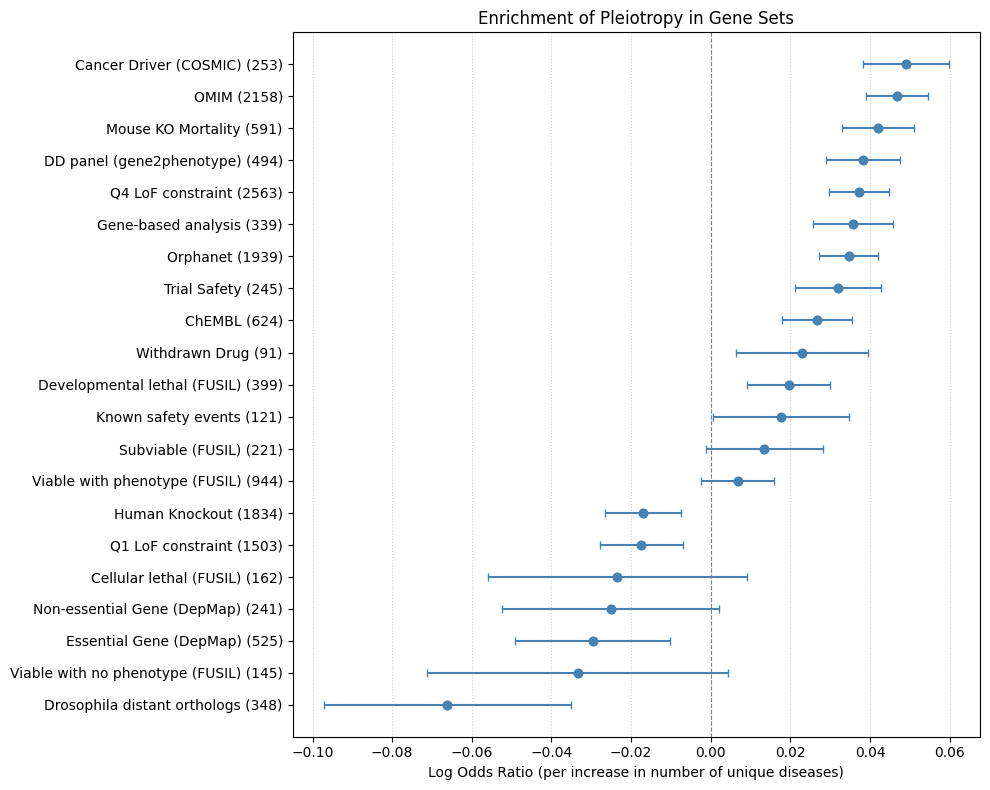

In [22]:
df_pd = genes_pleiotropy_categories.toPandas()

# 2. Explode the 'source' column to get one row per gene-category pair
df_exploded = df_pd.explode("source")

# 3. Calculate ORs for each category using Logistic Regression
# Model: In_Category ~ uniqueDiseases
results = []
all_categories = df_exploded["source"].unique()
df_pd["uniqueDiseases"] = df_pd["uniqueDiseases"]
for category in all_categories:
    if category is None:
        continue

    # Identify genes in this category
    genes_in_cat_ids = df_exploded[df_exploded["source"] == category]["geneId"].unique()

    # Define Target Variable: 1 if gene is in category, 0 otherwise
    df_pd["in_category"] = df_pd["geneId"].isin(genes_in_cat_ids).astype(int)

    # Skip categories with too few or too many genes (perfect separation risk)
    n_in_cat = df_pd["in_category"].sum()
    n_total = len(df_pd)
    if n_in_cat < 5 or n_in_cat > (n_total - 5):
        print(f"Skipping {category}: {n_in_cat}/{n_total} genes (too extreme)")
        continue

    # Define Predictor: uniqueDiseases (continuous)
    X = sm.add_constant(df_pd["uniqueDiseases"].astype(float))
    y = df_pd["in_category"]

    try:
        # Fit Logistic Regression
        model = sm.Logit(y, X).fit(disp=0)

        # Extract coefficients for uniqueDiseases
        log_or = model.params["uniqueDiseases"]
        p_value = model.pvalues["uniqueDiseases"]
        conf = model.conf_int()

        # 95% CI for Log Odds Ratio
        log_ci_lower = conf.loc["uniqueDiseases", 0]
        log_ci_upper = conf.loc["uniqueDiseases", 1]

        # Check for huge standard errors (non-convergence)
        if (log_ci_upper - log_ci_lower) > 10:  # Arbitrary large width check
            print(f"Skipping {category}: CI too wide ({log_ci_lower:.2f}, {log_ci_upper:.2f})")
            continue

        # Odds Ratio and its CI
        odds_ratio = np.exp(log_or)
        ci_lower = np.exp(log_ci_lower)
        ci_upper = np.exp(log_ci_upper)

        label = f"{category} ({n_in_cat})"

        results.append(
            {
                "category": category,
                "label": label,
                "odds_ratio": odds_ratio,
                "log_odds_ratio": log_or,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "log_ci_lower": log_ci_lower,
                "log_ci_upper": log_ci_upper,
                "p_value": p_value,
                "count": n_in_cat,
            }
        )
    except Exception as e:
        print(f"Skipping {category} due to error: {e}")

results_df = pd.DataFrame(results).sort_values("log_odds_ratio", ascending=True)

# 4. Plotting
plt.figure(figsize=(10, 8))

# Filter out categories with NaN CIs
plot_data = results_df.copy()

y_pos = np.arange(len(plot_data))

plt.errorbar(
    x=plot_data["log_odds_ratio"],
    y=y_pos,
    xerr=[
        plot_data["log_odds_ratio"] - plot_data["log_ci_lower"],
        plot_data["log_ci_upper"] - plot_data["log_odds_ratio"],
    ],
    fmt="o",
    color="steelblue",
    ecolor="steelblue",
    capsize=3,
)

# Apply specific colors to markers
for i, (idx, row) in enumerate(plot_data.iterrows()):
    color = "red" if "gwas" in row["category"].lower() else "steelblue"
    plt.plot(row["log_odds_ratio"], i, "o", color=color)

plt.yticks(y_pos, plot_data["label"])
plt.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Log Odds Ratio (per increase in number of unique diseases)")
plt.title("Enrichment of Pleiotropy in Gene Sets")
plt.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()
